In [ ]:
import os
import joblib
import optuna
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [54]:
BASE_PATH = '../dataset'
MODELS = os.path.join(BASE_PATH, 'models')
OUTPUT_PIPELINE = os.path.join(BASE_PATH, 'output_pipeline')
DATASET = os.path.join(BASE_PATH, 'dataset_produksi_padi.csv')

os.makedirs(os.path.join(OUTPUT_PIPELINE, 'linear_regression'), exist_ok=True)

In [55]:
df = pd.read_csv(DATASET)

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2529 entries, 0 to 2528
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   kabupaten           2529 non-null   object 
 1   luas_panen          2529 non-null   float64
 2   produktivitas       2529 non-null   float64
 3   produksi            2529 non-null   float64
 4   tahun               2529 non-null   int64  
 5   curah_hujan_rataan  2529 non-null   float64
 6   curah_hujan_total   2529 non-null   float64
 7   suhu_rataan         2529 non-null   float64
 8   suhu_maksimum       2529 non-null   float64
 9   suhu_minimum        2529 non-null   float64
 10  kelembapan_rataan   2529 non-null   float64
dtypes: float64(9), int64(1), object(1)
memory usage: 217.5+ KB


In [57]:
X_train = df.drop(columns=['kabupaten', 'produksi', 'produktivitas'])
y_train = df['produksi']

X_arr = X_train.to_numpy()
y_arr = y_train.to_numpy()

In [58]:
# Menghitung total seluruh data
total_baris = X_arr.shape[0]

print(f"=== RINGKASAN DATASET ===")
print(f"Total Keseluruhan Data: {total_baris} baris\n")
kf_check = KFold(n_splits=5, shuffle=True, random_state=42)

# Mengambil ukuran pembagian di dalam K-Fold pertama
for fold, (train_idx, val_idx) in enumerate(kf_check.split(X_arr), 1):
    jumlah_train = len(train_idx)
    jumlah_val = len(val_idx)
    
    print(f"Fold {fold}:")
    print(f"Jumlah Data Train: {jumlah_train} baris ({jumlah_train/total_baris*100:.1f}%)")
    print(f"Jumlah Data Validasi: {jumlah_val} baris ({jumlah_val/total_baris*100:.1f}%)")
    print(f"Jumlah Data Test: {jumlah_val} baris")
    break

=== RINGKASAN DATASET ===
Total Keseluruhan Data: 2529 baris

Fold 1:
Jumlah Data Train: 2023 baris (80.0%)
Jumlah Data Validasi: 506 baris (20.0%)
Jumlah Data Test: 506 baris


In [59]:
print("Mulai tuning Linear Regression (Bayesian - Optuna)")

def objective(trial):
    params = {
        "fit_intercept": trial.suggest_categorical("fit_intercept", [True, False]),
        "positive": trial.suggest_categorical("positive", [True, False]),
    }
    
    # Setup K-Fold di dalam Optuna
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scaler = StandardScaler()
    
    fold_mae_scores = []
    
    for train_idx, val_idx in kf.split(X_arr):
        X_train_f, X_val_f = X_arr[train_idx], X_arr[val_idx]
        y_train_f, y_val_f = y_arr[train_idx], y_arr[val_idx]
        
        # Scaling fitur per fold (mencegah data leakage)
        X_train_scaled = scaler.fit_transform(X_train_f)
        X_val_scaled = scaler.transform(X_val_f)
        
        # Inisialisasi model dengan parameter eksperimen Optuna
        model = LinearRegression(**params)
        model.fit(X_train_scaled, y_train_f)
        
        # Prediksi dan hitung MAE pada fold tersebut
        val_pred = model.predict(X_val_scaled)
        fold_mae_scores.append(mean_absolute_error(y_val_f, val_pred))
    return np.mean(fold_mae_scores)

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50, show_progress_bar=True)

best_params = study.best_params
best_mae = study.best_value

print(best_params)
print(f"Rata-rata MAE Terendah saat Tuning: {best_mae:.2f}\n")

[I 2026-06-10 22:53:58,202] A new study created in memory with name: no-name-70893165-ed6e-4a72-8177-38c7b700240b


Mulai tuning Linear Regression (Bayesian - Optuna)


Best trial: 0. Best value: 18550:  18%|█▊        | 9/50 [00:00<00:00, 65.68it/s]

[I 2026-06-10 22:53:58,224] Trial 0 finished with value: 18549.95406620872 and parameters: {'fit_intercept': True, 'positive': False}. Best is trial 0 with value: 18549.95406620872.
[I 2026-06-10 22:53:58,237] Trial 1 finished with value: 154494.1354671356 and parameters: {'fit_intercept': False, 'positive': False}. Best is trial 0 with value: 18549.95406620872.
[I 2026-06-10 22:53:58,252] Trial 2 finished with value: 154615.2882782055 and parameters: {'fit_intercept': False, 'positive': True}. Best is trial 0 with value: 18549.95406620872.
[I 2026-06-10 22:53:58,266] Trial 3 finished with value: 154494.1354671356 and parameters: {'fit_intercept': False, 'positive': False}. Best is trial 0 with value: 18549.95406620872.
[I 2026-06-10 22:53:58,280] Trial 4 finished with value: 154615.2882782055 and parameters: {'fit_intercept': False, 'positive': True}. Best is trial 0 with value: 18549.95406620872.
[I 2026-06-10 22:53:58,295] Trial 5 finished with value: 154494.1354671356 and parameter

Best trial: 9. Best value: 18484.6:  20%|██        | 10/50 [00:00<00:00, 65.68it/s]

...

[I 2026-06-10 22:53:59,036] Trial 47 finished with value: 154615.2882782055 and parameters: {'fit_intercept': False, 'positive': True}. Best is trial 9 with value: 18484.60478074826.


Best trial: 9. Best value: 18484.6:  96%|█████████▌| 48/50 [00:00<00:00, 58.25it/s]

[I 2026-06-10 22:53:59,054] Trial 48 finished with value: 18549.95406620872 and parameters: {'fit_intercept': True, 'positive': False}. Best is trial 9 with value: 18484.60478074826.


Best trial: 9. Best value: 18484.6: 100%|██████████| 50/50 [00:00<00:00, 57.62it/s]

[I 2026-06-10 22:53:59,072] Trial 49 finished with value: 18484.60478074826 and parameters: {'fit_intercept': True, 'positive': True}. Best is trial 9 with value: 18484.60478074826.
{'fit_intercept': True, 'positive': True}
Rata-rata MAE Terendah saat Tuning: 18484.60



In [60]:
def hitung_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

In [61]:
kf_final = KFold(n_splits=5, shuffle=True, random_state=42)
scaler_final = StandardScaler()
lr_model = LinearRegression(fit_intercept=True, positive=True)

fold_train_mae, fold_train_rmse, fold_train_r2 = [], [], []
fold_val_mae, fold_val_rmse, fold_val_r2 = [], [], []
y_aktual_total = []
y_prediksi_total = []

for fold, (train_idx, val_idx,) in enumerate(kf_final.split(X_arr), 1):
    X_train_f, X_val_f = X_arr[train_idx], X_arr[val_idx]
    y_train_f, y_val_f = y_arr[train_idx], y_arr[val_idx]
    
    X_train_scaled = scaler_final.fit_transform(X_train_f)
    X_val_scaled = scaler_final.transform(X_val_f)
    
    # Pelatihan Model
    lr_model.fit(X_train_scaled, y_train_f)
    
    # Prediksi untuk Train dan Validation pada fold saat ini
    train_pred_f = lr_model.predict(X_train_scaled)
    val_pred_f = lr_model.predict(X_val_scaled)
    
    # Hitung metrik per fold
    t_mae, t_rmse, t_r2 = hitung_metrics(y_train_f, train_pred_f)
    v_mae, v_rmse, v_r2 = hitung_metrics(y_val_f, val_pred_f)
    
    # Simpan hasil ke dalam list
    fold_train_mae.append(t_mae)
    fold_train_rmse.append(t_rmse)
    fold_train_r2.append(t_r2)
    
    fold_val_mae.append(v_mae)
    fold_val_rmse.append(v_rmse)
    fold_val_r2.append(v_r2)
    
    print(f"Fold {fold} -> Train R2: {t_r2:.4f} | Val R2: {v_r2:.4f}")

Fold 1 -> Train R2: 0.9767 | Val R2: 0.9804
Fold 2 -> Train R2: 0.9772 | Val R2: 0.9779
Fold 3 -> Train R2: 0.9777 | Val R2: 0.9758
Fold 4 -> Train R2: 0.9766 | Val R2: 0.9796
Fold 5 -> Train R2: 0.9787 | Val R2: 0.9712


In [62]:
print("=== PERFORMA LINEAR REGRESSION (TUNED) ===")
print("Rata-rata Train ")
print(f"MAE  : {np.mean(fold_train_mae):.4f}")
print(f"RMSE : {np.mean(fold_train_rmse):.4f}")
print(f"R2   : {np.mean(fold_train_r2):.4f} (±{np.std(fold_train_r2):.4f})")

print("\nRata-rata Validation / Cross-Validation")
print(f"MAE  : {np.mean(fold_val_mae):.4f}")
print(f"RMSE : {np.mean(fold_val_rmse):.4f}")
print(f"R2   : {np.mean(fold_val_r2):.4f} (±{np.std(fold_val_r2):.4f})")

=== PERFORMA LINEAR REGRESSION (TUNED) ===
Rata-rata Train 
MAE  : 18419.1639
RMSE : 32526.5288
R2   : 0.9774 (±0.0008)

Rata-rata Validation / Cross-Validation
MAE  : 18484.6048
RMSE : 32594.6237
R2   : 0.9770 (±0.0033)


In [63]:
# Simpan Model Linear Regression
joblib.dump(
    lr_model,
    os.path.join(MODELS, 'linear_regression.joblib')
)
print("Model berhasil disimpan.")

Model berhasil disimpan.


In [64]:
# Simpan metrics
metrics_lr = pd.DataFrame({
    "model": ["Linear Regression"],
    "train_mae": [fold_train_mae],
    "train_rmse": [fold_train_rmse],
    "train_r2": [fold_train_r2],
    "val_mae": [fold_val_mae],
    "val_rmse": [fold_val_rmse],
    "val_r2": [fold_val_r2],
})

metrics_lr.to_csv(
    os.path.join(OUTPUT_PIPELINE, "linear_regression/linear_regression_metrics.csv"),
    index=False
)
print("Metrics berhasil disimpan.")

Metrics berhasil disimpan.


In [65]:
# Simpan hasil prediksi test
y_aktual_total.extend(y_val_f)
y_prediksi_total.extend(val_pred_f)

df_hasil = pd.DataFrame({
    'Nilai Aktual': y_aktual_total,
    'Nilai Prediksi': y_prediksi_total
})

# Menghitung selisih (Error) antara Asli dan Prediksi
df_hasil['Selisih'] = np.abs(df_hasil['Nilai Aktual'] - df_hasil['Nilai Prediksi'])

print("=== 10 DATA HASIL PREDIKSI MODEL ===")
print(df_hasil.head(10).to_string(index=True, formatters={
    'Nilai Aktual': '{:,.2f}'.format,
    'Nilai Prediksi': '{:,.2f}'.format, 
    'Selisih': '{:,.2f}'.format
}))

df_hasil.to_csv(
    os.path.join(OUTPUT_PIPELINE, "linear_regression/linear_regression_predictions.csv"),
    index=False
)
print("Hasil prediksi berhasil disimpan.")

=== 10 DATA HASIL PREDIKSI MODEL ===
  Nilai Aktual Nilai Prediksi   Selisih
0     5,430.41      -2,964.69  8,395.10
1   174,531.52     164,080.02 10,451.50
2    91,836.92      74,705.96 17,130.96
3     2,435.45      -5,662.15  8,097.60
4     5,157.95      -1,879.08  7,037.03
5     2,440.92      -5,898.28  8,339.20
6    28,312.69      23,891.51  4,421.18
7    70,958.62      74,175.00  3,216.38
8    37,457.89      32,513.11  4,944.78
9     2,378.24      -5,607.30  7,985.54
Hasil prediksi berhasil disimpan.


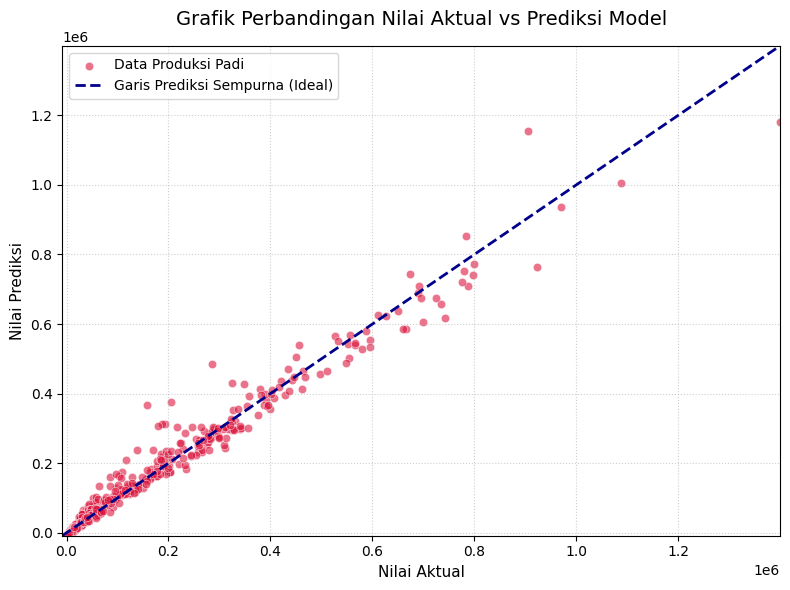

In [68]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_aktual_total, 
    y=y_prediksi_total, 
    alpha=0.6, 
    color='crimson', 
    edgecolor='w', 
    label='Data Produksi Padi'
)

lims = [
    min(min(y_aktual_total), min(y_prediksi_total)),  # nilai minimum
    max(max(y_aktual_total), max(y_prediksi_total))   # nilai maksimum
]
plt.plot(lims, lims, color='darkblue', linestyle='--', linewidth=2, label='Garis Prediksi Sempurna (Ideal)')

plt.title('Grafik Perbandingan Nilai Aktual vs Prediksi Model', fontsize=14, pad=15)
plt.xlabel('Nilai Aktual', fontsize=11)
plt.ylabel('Nilai Prediksi', fontsize=11)
plt.xlim(lims)
plt.ylim(lims)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_PIPELINE,'linear_regression/actual_vs_predicted.png'), 
    dpi=300, 
    bbox_inches='tight'
)
plt.show()